In [1]:
from google.colab import drive
import os
drive.mount('/content/drive')
project_path = '/content/drive/MyDrive/Customer_Churn_Thesis/'
os.chdir(project_path)
print("Project path:", project_path)

Mounted at /content/drive
Project path: /content/drive/MyDrive/Customer_Churn_Thesis/


In [2]:
DATA_PATH = os.path.join(project_path, "data/processed")
RESULTS_PATH = os.path.join(project_path, "results")

print("Project path:", project_path)

os.makedirs(f"{RESULTS_PATH}/figures", exist_ok=True)
os.makedirs(f"{RESULTS_PATH}/tables", exist_ok=True)

Project path: /content/drive/MyDrive/Customer_Churn_Thesis/


In [3]:
!pip install xgboost lightgbm shap

In [4]:
import pandas as pd
import numpy as np

from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score, roc_auc_score

from xgboost import XGBClassifier
import lightgbm as lgb

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
train = pd.read_csv(f"{DATA_PATH}/train_augmented.csv")
test = pd.read_csv(f"{DATA_PATH}/test_original.csv")

print(train.shape)
print(test.shape)

train.head()

(12740, 15)
(2000, 15)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Balance_Per_Product,Tenure_Age_Ratio,Is_Senior,Geography_Germany,Geography_Spain,Gender_Male,Exited
0,753,57,7,0.00,1,1,0,159475.08,0.000,0.122807,0,False,False,True,1
1,739,32,3,102128.27,1,1,0,63981.37,102128.270,0.093750,0,True,False,True,1
2,755,37,0,113865.23,2,1,1,117396.25,56932.615,0.000000,0,True,False,False,0
3,561,37,5,0.00,2,1,0,83093.25,0.000,0.135135,0,False,False,True,0
4,692,49,6,110540.43,2,0,1,107472.99,55270.215,0.122449,0,True,False,True,0


In [6]:
TARGET = "Exited"

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET]

X_test = test.drop(columns=[TARGET])
y_test = test[TARGET]

print(X_train.shape, X_test.shape)

(12740, 14) (2000, 14)


In [7]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

lgb_model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 6370, number of negative: 6370
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002349 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1369
[LightGBM] [Info] Number of data points in the train set: 12740, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

LGBMClassifier(learning_rate=0.05, max_depth=6, n_estimators=300,
               random_state=42)

In [8]:
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [9]:
lgb_probs = lgb_model.predict_proba(X_test)[:,1]
xgb_probs = xgb_model.predict_proba(X_test)[:,1]

hybrid_probs = (0.5 * lgb_probs) + (0.5 * xgb_probs)

hybrid_preds = (hybrid_probs > 0.5).astype(int)

In [10]:
from sklearn.metrics import precision_score
from sklearn.metrics import accuracy_score

precision = precision_score(y_test, hybrid_preds)
recall = recall_score(y_test, hybrid_preds)
f1 = f1_score(y_test, hybrid_preds)
roc = roc_auc_score(y_test, hybrid_probs)
accuracy = accuracy_score(y_test, hybrid_preds)

print("Hybrid Model Performance")
print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)
print("ROC-AUC:", roc)

Hybrid Model Performance
Accuracy: 0.837
Precision: 0.5961995249406176
Recall: 0.6167076167076168
F1: 0.606280193236715
ROC-AUC: 0.8467820671210501


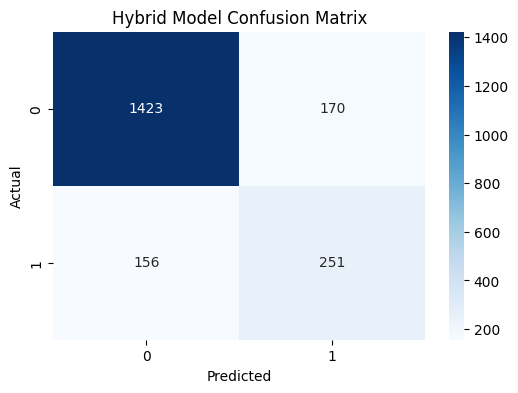

In [11]:
cm = confusion_matrix(y_test, hybrid_preds)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Hybrid Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig(f"{RESULTS_PATH}/figures/03_Hybrid_Model_Phase2_Hybrid_Model_Confusion_Matrix.png")
plt.show()

In [12]:
results = pd.DataFrame({
    "Model":["Hybrid_LightGBM_XGBoost"],
    "Accuracy":[accuracy],
    "Precision":[precision],
    "Recall":[recall],
    "F1":[f1],
    "ROC_AUC":[roc]
})
print(results)
results.to_csv(f"{RESULTS_PATH}/tables/03_Hybrid_Model_Phase2_hybrid_results.csv", index=False)

print("Results saved to Drive")

                     Model  Accuracy  Precision    Recall       F1   ROC_AUC
0  Hybrid_LightGBM_XGBoost     0.837     0.5962  0.616708  0.60628  0.846782
Results saved to Drive


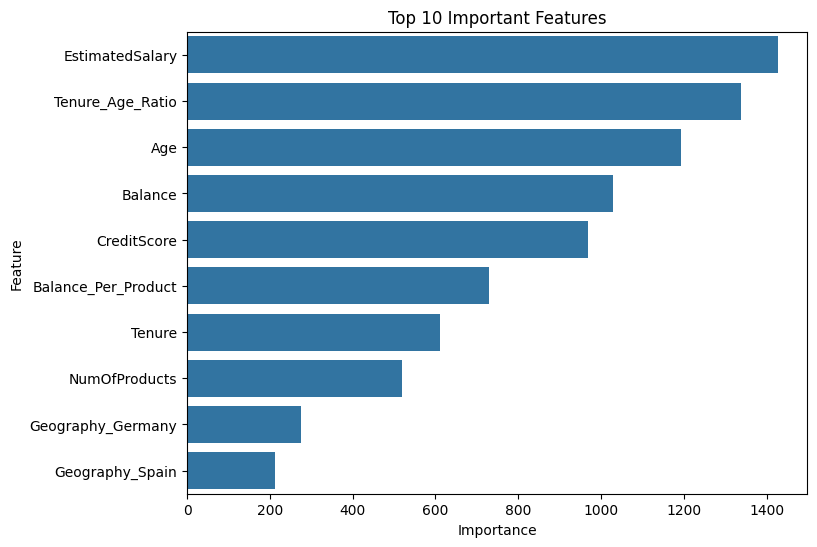

In [13]:
importances = lgb_model.feature_importances_

feat_imp = pd.DataFrame({
    "Feature":X_train.columns,
    "Importance":importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(data=feat_imp.head(10), x="Importance", y="Feature")

plt.title("Top 10 Important Features")
plt.savefig(f"{RESULTS_PATH}/figures/03_Hybrid_Model_Phase2_Top_10_Important_Features.png")
plt.show()